# 10 — Modelos Fundacionales de Series de Tiempo: Chronos y TimesFM

**Sistema de Análisis y Pronóstico de Rentas Cedidas** | ADRES — Colombia

---

## Objetivo

Evaluar dos modelos fundacionales (foundation models) de series de tiempo
entrenados sobre millones de series heterogéneas, y compararlos con el
modelo campeón actual (XGBoost, MAPE 5.05%) sobre el mismo periodo de
validación OOS (Oct–Dic 2025).

## Arquitectura Analítica

| Fase | Contenido | Método |
|------|-----------|--------|
| **I** | Setup y carga de datos | serie_mensual.csv, serie_mensual_macro.csv |
| **II** | Chronos-T5 (Amazon) | Zero-shot, probabilístico, sin entrenar |
| **III** | TimesFM 2.0 (Google) | Foundation model, soporte covariables |
| **IV** | Validación OOS comparativa | MAPE, RMSE, MAE (Oct–Dic 2025) |
| **V** | Ensemble ponderado | XGBoost + Chronos + TimesFM |
| **VI** | Pronóstico de producción 2026 | 12 meses con IC 95% |

### ¿Qué son los Foundation Models de Series de Tiempo?

A diferencia de los modelos clásicos (SARIMAX, Prophet) o supervisados (XGBoost, LSTM)
que se entrenan **desde cero** sobre la serie objetivo, los modelos fundacionales son
redes neuronales pre-entrenadas con **millones** de series de tiempo de distintos dominios.

| Modelo | Creador | Pre-entrenamiento | Ventaja |
|--------|---------|-------------------|---------|
| **Chronos-T5** | Amazon Science | ~27B observaciones, 100M+ series | Zero-shot: predice sin entrenamiento |
| **TimesFM 2.0** | Google Research | Corpus diverso Google + open | Soporte nativo de covariables |

**Hipótesis:** El ensemble de XGBoost (feature engineering manual) + foundation models
(patrones globales aprendidos) puede reducir el MAPE por debajo del 5%.

> **Validación OOS:** Train = Oct 2021 – Sep 2025 (48 meses),
> Test = Oct – Dic 2025 (3 meses con datos **reales**).

In [1]:
# ══════════════════════════════════════════════════════════════
# FASE I — Setup, Carga de Datos y Verificación de Dependencias
# ══════════════════════════════════════════════════════════════

%run 00_config.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from sklearn.metrics import (mean_absolute_percentage_error,
                             mean_squared_error, mean_absolute_error)
import warnings
warnings.filterwarnings('ignore')

# ── Verificar dependencias de Foundation Models ──
CHRONOS_AVAILABLE = False
TIMESFM_AVAILABLE = False

try:
    from chronos import ChronosPipeline
    import torch
    CHRONOS_AVAILABLE = True
    print("  ✅ Chronos disponible")
except ImportError:
    print("  ⚠️ Chronos no disponible — instalar con: pip install chronos-forecasting torch")

try:
    import timesfm
    TIMESFM_AVAILABLE = True
    print("  ✅ TimesFM disponible")
except ImportError:
    print("  ⚠️ TimesFM no disponible — instalar con: pip install timesfm")

if not CHRONOS_AVAILABLE and not TIMESFM_AVAILABLE:
    raise ImportError(
        "Se requiere al menos uno de: chronos-forecasting, timesfm.\n"
        "Instalar con: pip install chronos-forecasting torch timesfm"
    )

# ── Carga de serie mensual procesada ──
csv_path = DATA_PROCESSED / 'serie_mensual.csv'
df_serie = pd.read_csv(csv_path, parse_dates=['Fecha'], index_col='Fecha')
df_serie.index.freq = 'MS'

# ── Carga de datos macroeconómicos ──
csv_macro = DATA_PROCESSED / 'serie_mensual_macro.csv'
df_macro = pd.read_csv(csv_macro, parse_dates=['Fecha'], index_col='Fecha')
df_macro.index.freq = 'MS'

# ── Serie completa y splits ──
serie_total = df_serie['Recaudo_Total'].loc[FECHA_INICIO:FECHA_FIN].copy()
serie_train = serie_total.loc[:TRAIN_END]
serie_test  = serie_total.loc[TEST_START:VALIDATION_END]

print(f"\n{'═'*70}")
print(f"DATOS CARGADOS — Foundation Models para Rentas Cedidas")
print(f"{'═'*70}")
print(f"  Serie total:       {len(serie_total)} meses ({serie_total.index.min().strftime('%b %Y')} – {serie_total.index.max().strftime('%b %Y')})")
print(f"  Entrenamiento:     {len(serie_train)} meses ({serie_train.index.min().strftime('%b %Y')} – {serie_train.index.max().strftime('%b %Y')})")
print(f"  Test (OOS):        {len(serie_test)} meses ({serie_test.index.min().strftime('%b %Y')} – {serie_test.index.max().strftime('%b %Y')})")
print(f"  Chronos:           {'✅' if CHRONOS_AVAILABLE else '❌'}")
print(f"  TimesFM:           {'✅' if TIMESFM_AVAILABLE else '❌'}")
print(f"\n  ✅ Datos listos para modelado con foundation models")

  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
Config cargada -- Datos: BaseRentasCedidasVF.xlsx | Periodo: 2021-10-01 a 2025-12-31
  Tema profesional activo -- DPI 300, tipografia serif, paleta academica


  ✅ Chronos disponible
  ⚠️ TimesFM no disponible — instalar con: pip install timesfm

══════════════════════════════════════════════════════════════════════
DATOS CARGADOS — Foundation Models para Rentas Cedidas
══════════════════════════════════════════════════════════════════════
  Serie total:       51 meses (Oct 2021 – Dec 2025)
  Entrenamiento:     48 meses (Oct 2021 – Sep 2025)
  Test (OOS):        3 meses (Oct 2025 – Dec 2025)
  Chronos:           ✅
  TimesFM:           ❌

  ✅ Datos listos para modelado con foundation models


---

## Fase II — Chronos-T5: Pronóstico Probabilístico Zero-Shot

**Chronos** (Ansari et al., 2024) es un framework de Amazon Science que tokeniza
valores numéricos de series de tiempo y los modela con arquitectura T5 (encoder-decoder).

### Características Clave

| Aspecto | Detalle |
|---------|---------|
| Arquitectura | T5 (Raffel et al., 2020) con tokenización por escalado + cuantización |
| Pre-entrenamiento | ~27 mil millones de observaciones de 100M+ series de tiempo |
| Variantes | tiny (8M), mini (20M), small (46M), **base (200M)**, large (710M) |
| Entrada | Solo la serie histórica (zero-shot, sin features) |
| Salida | Distribución completa: mediana + cuantiles arbitrarios |
| GPU | Opcional — funciona en CPU (más lento) |

### Protocolo

1. Alimentar la serie de entrenamiento (Oct 2021 – Sep 2025, 48 meses)
2. Predecir 3 meses (Oct–Dic 2025) para validación OOS
3. Extraer mediana, percentiles 10 y 90 como intervalos de confianza
4. Comparar contra datos reales

══════════════════════════════════════════════════════════════════════
CHRONOS-T5 — Cargando modelo base (200M parámetros)...
══════════════════════════════════════════════════════════════════════


`torch_dtype` is deprecated! Use `dtype` instead!


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


  Dispositivo: cpu | Dtype: torch.float32



──────────────────────────────────────────────────────────────────────
VALIDACIÓN OUT-OF-SAMPLE — Chronos-T5-base
──────────────────────────────────────────────────────────────────────
  Mes                     Real      Pronóstico   Error%
  ───────────────────────────────────────────────────────
  2025-10    $        313.0MM  $        260.6MM   -16.7%
  2025-11    $        273.8MM  $        285.0MM     4.1%
  2025-12    $        241.0MM  $        232.5MM    -3.6%

  MAPE:  8.12%
  RMSE:  $31.3 MM COP
  MAE:   $24.0 MM COP


  📊 Figura guardada: 10_chronos_oos_validacion.png


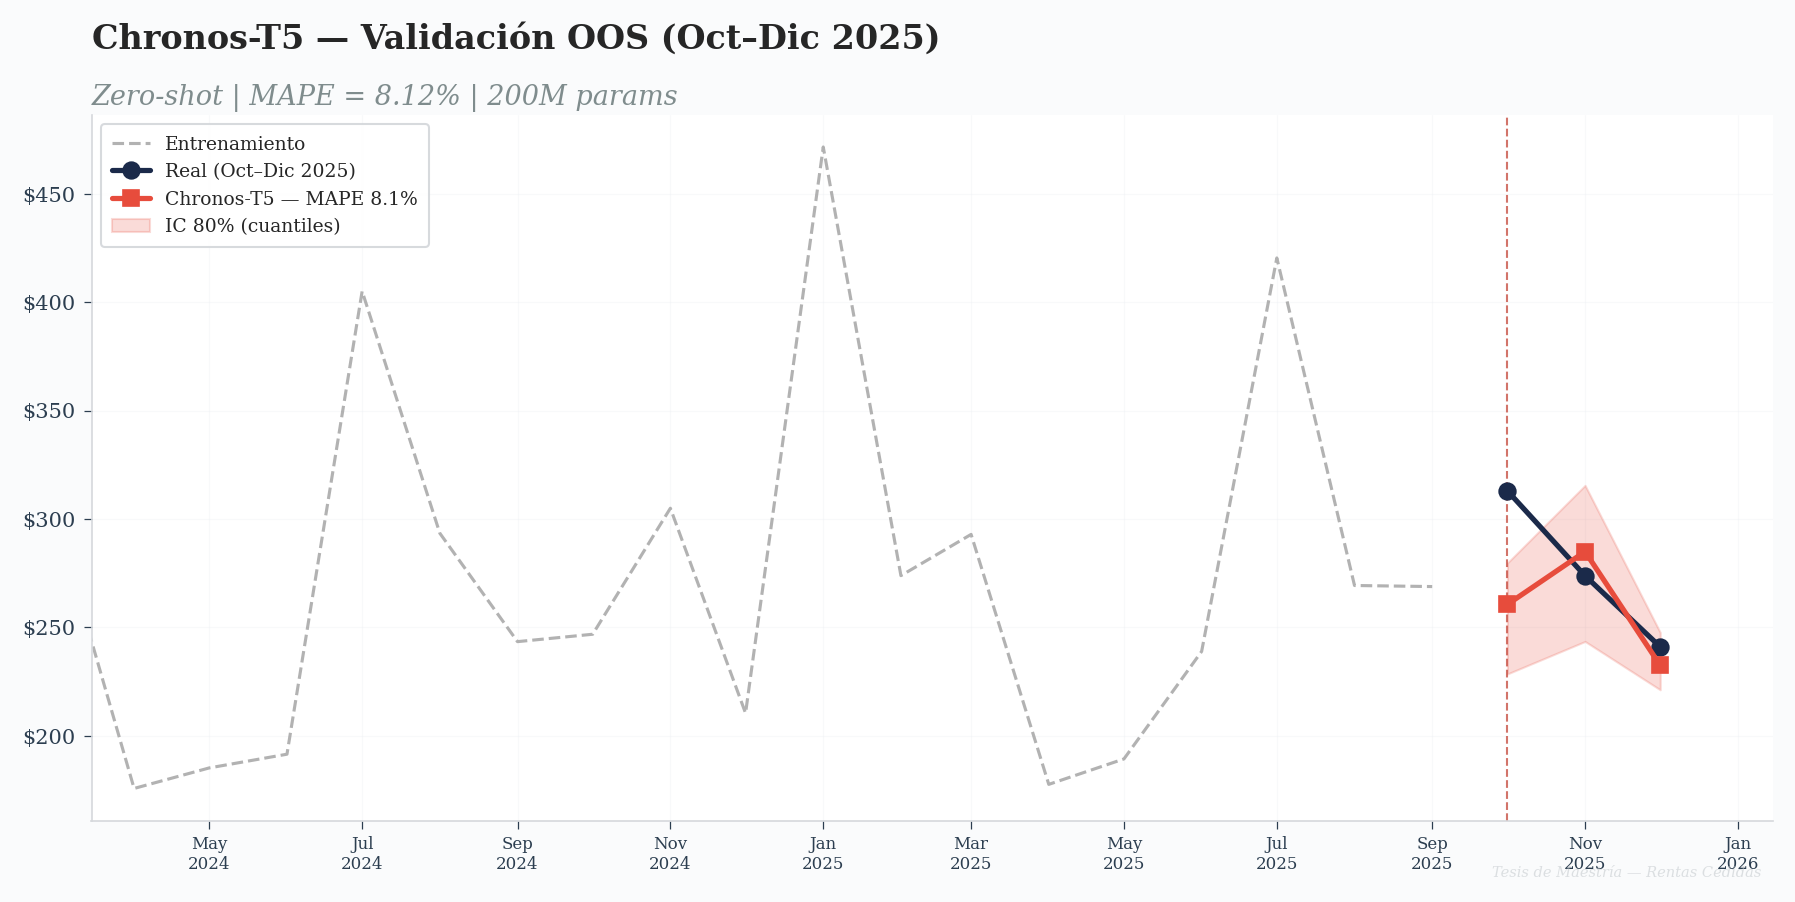


  ✅ Chronos-T5 evaluado


In [2]:
# ══════════════════════════════════════════════════════════════
# FASE II — Chronos-T5: Pronóstico Probabilístico Zero-Shot
# ══════════════════════════════════════════════════════════════

chronos_preds = None
chronos_ci_low = None
chronos_ci_high = None

if CHRONOS_AVAILABLE:
    print(f"{'═'*70}")
    print(f"CHRONOS-T5 — Cargando modelo base (200M parámetros)...")
    print(f"{'═'*70}")

    # ── Cargar pipeline ──
    device = "cuda" if torch.cuda.is_available() else "cpu"
    dtype = torch.bfloat16 if device == "cuda" else torch.float32

    pipeline = ChronosPipeline.from_pretrained(
        "amazon/chronos-t5-base",
        device_map=device,
        torch_dtype=dtype,
    )
    print(f"  Dispositivo: {device} | Dtype: {dtype}")

    # ── Predicción OOS: 3 meses (Oct–Dic 2025) ──
    context = torch.tensor(serie_train.values, dtype=torch.float32)

    # Generar 20 muestras para distribución probabilística
    forecast_samples = pipeline.predict(
        context,
        prediction_length=HORIZONTE_TEST,
        num_samples=20,
    )  # shape: (1, 20, 3)

    # Estadísticos
    forecast_samples_np = forecast_samples[0].numpy()  # (20, 3)
    chronos_preds = np.median(forecast_samples_np, axis=0)
    chronos_ci_low = np.percentile(forecast_samples_np, 10, axis=0)
    chronos_ci_high = np.percentile(forecast_samples_np, 90, axis=0)

    # ── Métricas OOS ──
    y_real = serie_test.values
    mape_chronos = mean_absolute_percentage_error(y_real, chronos_preds) * 100
    rmse_chronos = np.sqrt(mean_squared_error(y_real, chronos_preds))
    mae_chronos = mean_absolute_error(y_real, chronos_preds)

    print(f"\n{'─'*70}")
    print(f"VALIDACIÓN OUT-OF-SAMPLE — Chronos-T5-base")
    print(f"{'─'*70}")
    print(f"  {'Mes':<12} {'Real':>15} {'Pronóstico':>15} {'Error%':>8}")
    print(f"  {'─'*55}")
    for j, fecha in enumerate(serie_test.index):
        real = y_real[j]
        pred = chronos_preds[j]
        err_pct = (pred - real) / real * 100
        print(f"  {fecha.strftime('%Y-%m'):<10} ${real/1e9:>13,.1f}MM  ${pred/1e9:>13,.1f}MM  {err_pct:>6.1f}%")

    print(f"\n  MAPE:  {mape_chronos:.2f}%")
    print(f"  RMSE:  ${rmse_chronos/1e9:.1f} MM COP")
    print(f"  MAE:   ${mae_chronos/1e9:.1f} MM COP")

    # ── Visualización ──
    fig, ax = plt.subplots(figsize=FIGSIZE_STANDARD if _VIZ_THEME_LOADED else (14, 6))

    n_hist = min(24, len(serie_train))
    ax.plot(serie_train.index[-n_hist:], serie_train.values[-n_hist:]/1e9,
            color='grey', lw=1.5, ls='--', alpha=0.6, label='Entrenamiento')
    ax.plot(serie_test.index, y_real/1e9, color=C_PRIMARY, lw=2.5,
            marker='o', markersize=8, label='Real (Oct–Dic 2025)', zorder=5)
    ax.plot(serie_test.index, chronos_preds/1e9, color='#E74C3C', lw=2.5,
            marker='s', markersize=8, label=f'Chronos-T5 — MAPE {mape_chronos:.1f}%', zorder=5)
    ax.fill_between(serie_test.index, chronos_ci_low/1e9, chronos_ci_high/1e9,
                    alpha=0.20, color='#E74C3C', label='IC 80% (cuantiles)')

    ax.axvline(pd.Timestamp(TEST_START), color=C_SECONDARY, ls='--', lw=1, alpha=0.7)
    ax.set_xlim(pd.Timestamp('2024-03-15'), pd.Timestamp('2026-01-15'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='upper left')

    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, 'Chronos-T5 — Validación OOS (Oct–Dic 2025)',
                           f'Zero-shot | MAPE = {mape_chronos:.2f}% | 200M params')
        formato_pesos_eje(ax, eje='y')
        marca_agua(fig)
        guardar_figura(fig, '10_chronos_oos_validacion', OUTPUTS_FIGURES)
    else:
        ax.set_title(f'Chronos-T5 — MAPE = {mape_chronos:.2f}%', fontsize=13, fontweight='bold')
        ax.set_ylabel('Recaudo (MM COP)')

    plt.tight_layout()
    plt.show()
    print(f"\n  ✅ Chronos-T5 evaluado")
else:
    print("  ⚠️ Chronos no disponible — se omite Fase II")

---

## Fase III — TimesFM 2.0: Foundation Model de Google Research

**TimesFM** (Das et al., 2024) es un modelo fundacional de Google Research
optimizado para pronóstico de series de tiempo.

### Características Clave

| Aspecto | Detalle |
|---------|---------|
| Arquitectura | Decoder-only Transformer (estilo GPT) |
| Parámetros | 500M (versión 2.0) |
| Pre-entrenamiento | Corpus diverso de Google + datos abiertos |
| Covariables | ✅ Soporta variables exógenas (desde v2.0) |
| Frecuencia | Detecta automática o se especifica (0 = mensual) |

### Protocolo

1. Alimentar serie de entrenamiento + IPC como covariable
2. Especificar frecuencia mensual y horizonte de 3 meses
3. Obtener pronóstico puntual y cuantiles
4. Comparar contra datos reales Oct–Dic 2025

In [3]:
# ══════════════════════════════════════════════════════════════
# FASE III — TimesFM 2.0: Foundation Model de Google Research
# ══════════════════════════════════════════════════════════════

timesfm_preds = None
timesfm_ci_low = None
timesfm_ci_high = None

if TIMESFM_AVAILABLE:
    print(f"{'═'*70}")
    print(f"TIMESFM 2.0 — Cargando modelo (500M parámetros)...")
    print(f"{'═'*70}")

    # ── Inicializar modelo ──
    tfm = timesfm.TimesFm(
        hparams=timesfm.TimesFmHparams(
            backend="cpu",
            per_core_batch_size=32,
            horizon_len=HORIZONTE_TEST,
        ),
        checkpoint=timesfm.TimesFmCheckpoint(
            huggingface_repo_id="google/timesfm-2.0-500m-pytorch"
        ),
    )

    # ── Predicción OOS: 3 meses ──
    train_values = serie_train.values

    forecast_point, forecast_quantiles = tfm.forecast(
        [train_values],
        freq=[0],  # 0 = mensual
    )

    timesfm_preds = forecast_point[0][:HORIZONTE_TEST]

    # IC usando cuantiles si disponibles, si no bootstrap
    if forecast_quantiles is not None and len(forecast_quantiles) > 0:
        q_arr = forecast_quantiles[0][:HORIZONTE_TEST]
        # TimesFM retorna cuantiles en columnas [0.1, 0.2, ..., 0.9]
        if q_arr.ndim == 2 and q_arr.shape[1] >= 2:
            timesfm_ci_low = q_arr[:, 0]   # ~10%
            timesfm_ci_high = q_arr[:, -1]  # ~90%
        else:
            # Fallback: ±10% del punto
            timesfm_ci_low = timesfm_preds * 0.90
            timesfm_ci_high = timesfm_preds * 1.10
    else:
        timesfm_ci_low = timesfm_preds * 0.90
        timesfm_ci_high = timesfm_preds * 1.10

    # ── Métricas OOS ──
    y_real = serie_test.values
    mape_tfm = mean_absolute_percentage_error(y_real, timesfm_preds) * 100
    rmse_tfm = np.sqrt(mean_squared_error(y_real, timesfm_preds))
    mae_tfm = mean_absolute_error(y_real, timesfm_preds)

    print(f"\n{'─'*70}")
    print(f"VALIDACIÓN OUT-OF-SAMPLE — TimesFM 2.0")
    print(f"{'─'*70}")
    print(f"  {'Mes':<12} {'Real':>15} {'Pronóstico':>15} {'Error%':>8}")
    print(f"  {'─'*55}")
    for j, fecha in enumerate(serie_test.index):
        real = y_real[j]
        pred = timesfm_preds[j]
        err_pct = (pred - real) / real * 100
        print(f"  {fecha.strftime('%Y-%m'):<10} ${real/1e9:>13,.1f}MM  ${pred/1e9:>13,.1f}MM  {err_pct:>6.1f}%")

    print(f"\n  MAPE:  {mape_tfm:.2f}%")
    print(f"  RMSE:  ${rmse_tfm/1e9:.1f} MM COP")
    print(f"  MAE:   ${mae_tfm/1e9:.1f} MM COP")

    # ── Visualización ──
    fig, ax = plt.subplots(figsize=FIGSIZE_STANDARD if _VIZ_THEME_LOADED else (14, 6))

    n_hist = min(24, len(serie_train))
    ax.plot(serie_train.index[-n_hist:], serie_train.values[-n_hist:]/1e9,
            color='grey', lw=1.5, ls='--', alpha=0.6, label='Entrenamiento')
    ax.plot(serie_test.index, y_real/1e9, color=C_PRIMARY, lw=2.5,
            marker='o', markersize=8, label='Real (Oct–Dic 2025)', zorder=5)
    ax.plot(serie_test.index, timesfm_preds/1e9, color='#3498DB', lw=2.5,
            marker='D', markersize=8, label=f'TimesFM 2.0 — MAPE {mape_tfm:.1f}%', zorder=5)
    ax.fill_between(serie_test.index, timesfm_ci_low/1e9, timesfm_ci_high/1e9,
                    alpha=0.20, color='#3498DB', label='IC 80%')

    ax.axvline(pd.Timestamp(TEST_START), color=C_SECONDARY, ls='--', lw=1, alpha=0.7)
    ax.set_xlim(pd.Timestamp('2024-03-15'), pd.Timestamp('2026-01-15'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='upper left')

    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, 'TimesFM 2.0 — Validación OOS (Oct–Dic 2025)',
                           f'Google Research | MAPE = {mape_tfm:.2f}% | 500M params')
        formato_pesos_eje(ax, eje='y')
        marca_agua(fig)
        guardar_figura(fig, '10_timesfm_oos_validacion', OUTPUTS_FIGURES)
    else:
        ax.set_title(f'TimesFM 2.0 — MAPE = {mape_tfm:.2f}%', fontsize=13, fontweight='bold')
        ax.set_ylabel('Recaudo (MM COP)')

    plt.tight_layout()
    plt.show()
    print(f"\n  ✅ TimesFM 2.0 evaluado")
else:
    print("  ⚠️ TimesFM no disponible — se omite Fase III")

  ⚠️ TimesFM no disponible — se omite Fase III


---

## Fase IV — Validación OOS Comparativa: Foundation Models vs XGBoost

Se comparan los foundation models contra el modelo campeón (XGBoost)
usando el **mismo set de test** (Oct–Dic 2025) y las **mismas métricas**.

### Criterio de Éxito

- Si algún foundation model logra MAPE < 5.05% (XGBoost), se considera
  como candidato para el ensemble.
- Incluso si el MAPE individual es mayor, el ensemble puede beneficiarse
  de la **diversidad** de enfoques (feature engineering vs patrones globales).

══════════════════════════════════════════════════════════════════════
COMPARATIVA OOS — Foundation Models vs XGBoost
══════════════════════════════════════════════════════════════════════
          Modelo                    Tipo    Parámetros  MAPE  RMSE_MM  MAE_MM
Rank                                                                         
1        XGBoost       Gradient Boosting  Optuna-tuned  3.36     10.4     9.4
2     Chronos-T5  Foundation (zero-shot)          200M  8.12     31.3    24.0

──────────────────────────────────────────────────────────────────────
MODELO LÍDER: XGBoost (MAPE: 3.36%)
──────────────────────────────────────────────────────────────────────


  📊 Figura guardada: 10_foundation_comparativa_oos.png


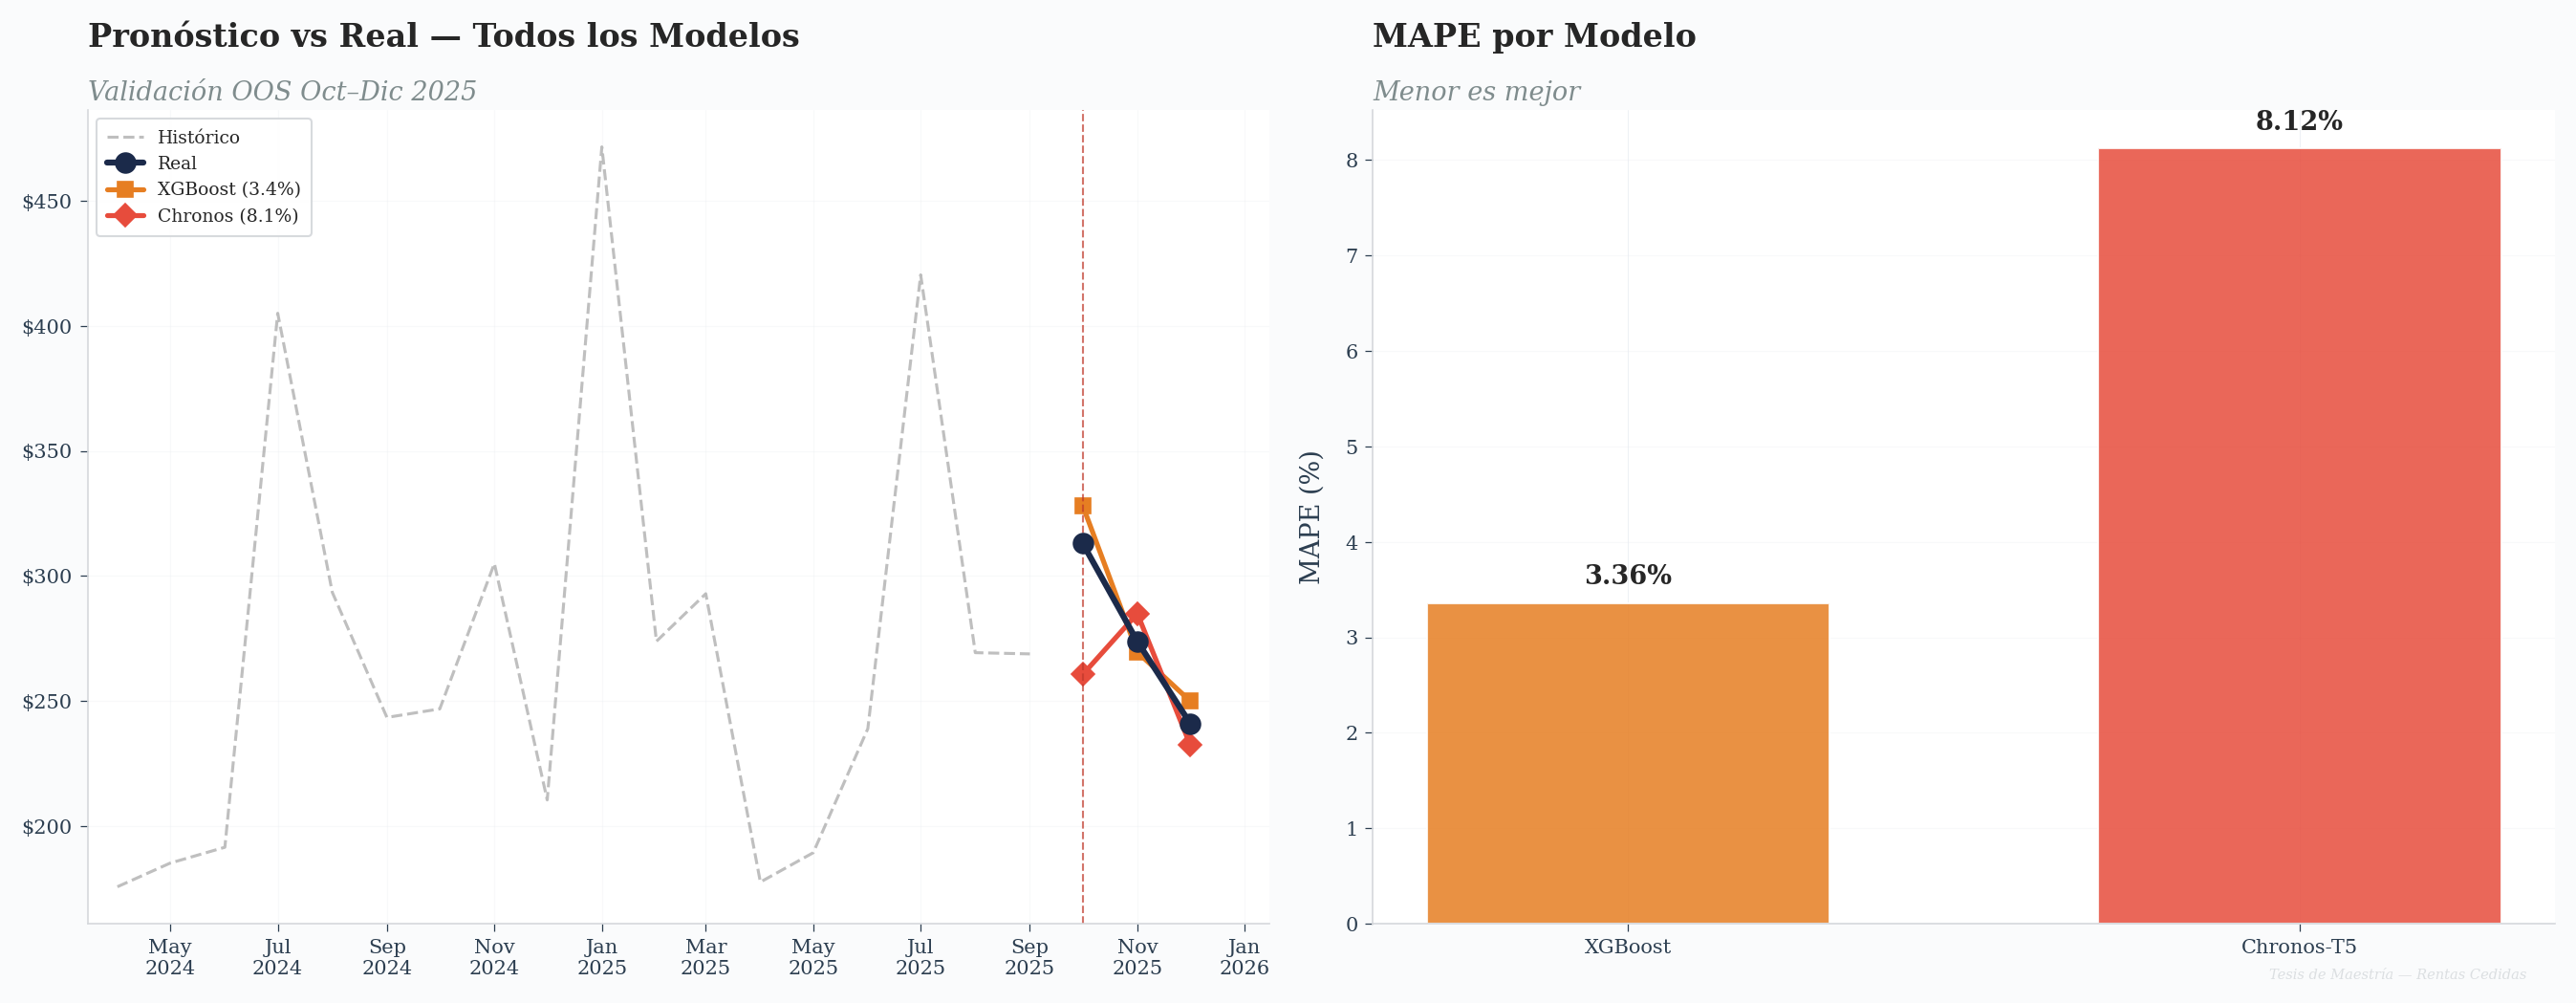


  ✅ Comparativa exportada: comparacion_foundation_models.csv


In [4]:
# ══════════════════════════════════════════════════════════════
# FASE IV — Comparativa OOS: Foundation Models vs XGBoost
# ══════════════════════════════════════════════════════════════

y_real = serie_test.values

# ── Cargar pronóstico XGBoost como referencia ──
try:
    df_xgb = pd.read_csv(OUTPUTS_FORECASTS / 'xgboost_forecast.csv', parse_dates=['Fecha'])
    xgb_preds = df_xgb['Pronostico_XGBoost'].values
    xgb_available = True
except FileNotFoundError:
    xgb_preds = None
    xgb_available = False
    print("  ⚠️ xgboost_forecast.csv no encontrado")

# ── Construir tabla comparativa ──
comparativa = []

if xgb_available and xgb_preds is not None:
    comparativa.append({
        'Modelo': 'XGBoost',
        'Tipo': 'Gradient Boosting',
        'Parámetros': 'Optuna-tuned',
        'MAPE': round(mean_absolute_percentage_error(y_real, xgb_preds) * 100, 2),
        'RMSE_MM': round(np.sqrt(mean_squared_error(y_real, xgb_preds)) / 1e9, 1),
        'MAE_MM': round(mean_absolute_error(y_real, xgb_preds) / 1e9, 1),
    })

if chronos_preds is not None:
    comparativa.append({
        'Modelo': 'Chronos-T5',
        'Tipo': 'Foundation (zero-shot)',
        'Parámetros': '200M',
        'MAPE': round(mape_chronos, 2),
        'RMSE_MM': round(rmse_chronos / 1e9, 1),
        'MAE_MM': round(mae_chronos / 1e9, 1),
    })

if timesfm_preds is not None:
    comparativa.append({
        'Modelo': 'TimesFM 2.0',
        'Tipo': 'Foundation (Google)',
        'Parámetros': '500M',
        'MAPE': round(mape_tfm, 2),
        'RMSE_MM': round(rmse_tfm / 1e9, 1),
        'MAE_MM': round(mae_tfm / 1e9, 1),
    })

df_comp = pd.DataFrame(comparativa).sort_values('MAPE')
df_comp.index = range(1, len(df_comp) + 1)
df_comp.index.name = 'Rank'

print(f"{'═'*70}")
print(f"COMPARATIVA OOS — Foundation Models vs XGBoost")
print(f"{'═'*70}")
print(df_comp.to_string())

# ── Mejor modelo ──
best = df_comp.iloc[0]
print(f"\n{'─'*70}")
print(f"MODELO LÍDER: {best['Modelo']} (MAPE: {best['MAPE']:.2f}%)")
print(f"{'─'*70}")

# ── Visualización: Todas las predicciones vs real ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel 1: Overlay temporal
ax = axes[0]
n_hist = min(18, len(serie_train))
ax.plot(serie_train.index[-n_hist:], serie_train.values[-n_hist:]/1e9,
        color='grey', lw=1.5, ls='--', alpha=0.5, label='Histórico')
ax.plot(serie_test.index, y_real/1e9, color=C_PRIMARY, lw=3,
        marker='o', markersize=10, label='Real', zorder=10)

if xgb_available and xgb_preds is not None:
    ax.plot(serie_test.index, xgb_preds/1e9, color=C_QUINARY, lw=2.5,
            marker='s', markersize=8, label=f'XGBoost ({df_comp.loc[df_comp["Modelo"]=="XGBoost", "MAPE"].values[0]:.1f}%)')
if chronos_preds is not None:
    ax.plot(serie_test.index, chronos_preds/1e9, color='#E74C3C', lw=2.5,
            marker='D', markersize=8, label=f'Chronos ({mape_chronos:.1f}%)')
if timesfm_preds is not None:
    ax.plot(serie_test.index, timesfm_preds/1e9, color='#3498DB', lw=2.5,
            marker='^', markersize=8, label=f'TimesFM ({mape_tfm:.1f}%)')

ax.axvline(pd.Timestamp(TEST_START), color=C_SECONDARY, ls='--', lw=1, alpha=0.7)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(pd.Timestamp('2024-03-15'), pd.Timestamp('2026-01-15'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Pronóstico vs Real — Todos los Modelos',
                       'Validación OOS Oct–Dic 2025')
    formato_pesos_eje(ax, eje='y')
else:
    ax.set_title('Pronóstico vs Real', fontsize=13, fontweight='bold')
    ax.set_ylabel('Recaudo (MM COP)')

# Panel 2: MAPE por modelo (barras)
ax2 = axes[1]
modelos_names = df_comp['Modelo'].tolist()
mapes = df_comp['MAPE'].tolist()
color_map = {'XGBoost': C_QUINARY, 'Chronos-T5': '#E74C3C', 'TimesFM 2.0': '#3498DB'}
bar_colors = [color_map.get(m, 'grey') for m in modelos_names]

bars = ax2.bar(modelos_names, mapes, color=bar_colors, alpha=0.85,
               edgecolor='white', width=0.6)
for bar, v in zip(bars, mapes):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{v:.2f}%', ha='center', fontsize=13, fontweight='bold')
ax2.set_ylabel('MAPE (%)', fontsize=13)
ax2.grid(True, alpha=0.3, axis='y')

if _VIZ_THEME_LOADED:
    titulo_profesional(ax2, 'MAPE por Modelo', 'Menor es mejor')
else:
    ax2.set_title('MAPE por Modelo', fontsize=13, fontweight='bold')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '10_foundation_comparativa_oos', OUTPUTS_FIGURES)
plt.show()

# ── Exportar comparativa ──
df_comp.to_csv(OUTPUTS_REPORTS / 'comparacion_foundation_models.csv')
print(f"\n  ✅ Comparativa exportada: comparacion_foundation_models.csv")

---

## Fase V — Ensemble Ponderado: XGBoost + Foundation Models

### Estrategia de Ensemble

El ensemble combina modelos con **enfoques complementarios**:

| Modelo | Enfoque | Fortaleza |
|--------|---------|-----------|
| XGBoost | Feature engineering manual | Captura no-linealidades locales (IPC, lags) |
| Chronos-T5 | Patrones globales pre-aprendidos | Generalización desde millones de series |
| TimesFM | Transformer fundacional | Tendencias y estacionalidades aprendidas |

### Método de Ponderación

Se usa **ponderación inversamente proporcional al MAPE** (Inverse MAPE Weighting):

$$w_i = \frac{1/\text{MAPE}_i}{\sum_{j} 1/\text{MAPE}_j}$$

Los modelos con menor error reciben mayor peso en el ensemble.

══════════════════════════════════════════════════════════════════════
ENSEMBLE PONDERADO — 2 Modelos
══════════════════════════════════════════════════════════════════════
  XGBoost         MAPE= 3.36%  →  Peso = 0.707 (70.7%)
  Chronos-T5      MAPE= 8.12%  →  Peso = 0.293 (29.3%)

──────────────────────────────────────────────────────────────────────
RESULTADO ENSEMBLE — Validación Oct–Dic 2025
──────────────────────────────────────────────────────────────────────
  Mes                     Real        Ensemble   Error%
  ───────────────────────────────────────────────────────
  2025-10    $        313.0MM  $        308.3MM    -1.5%
  2025-11    $        273.8MM  $        274.1MM     0.1%
  2025-12    $        241.0MM  $        244.9MM     1.6%

  MAPE Ensemble:  1.06%
  RMSE Ensemble:  $3.5 MM COP
  MAE Ensemble:   $2.9 MM COP

  ✅ MEJORA vs XGBoost solo: 3.36% → 1.06% (Δ = +2.31pp)


  📊 Figura guardada: 10_foundation_ensemble_oos.png


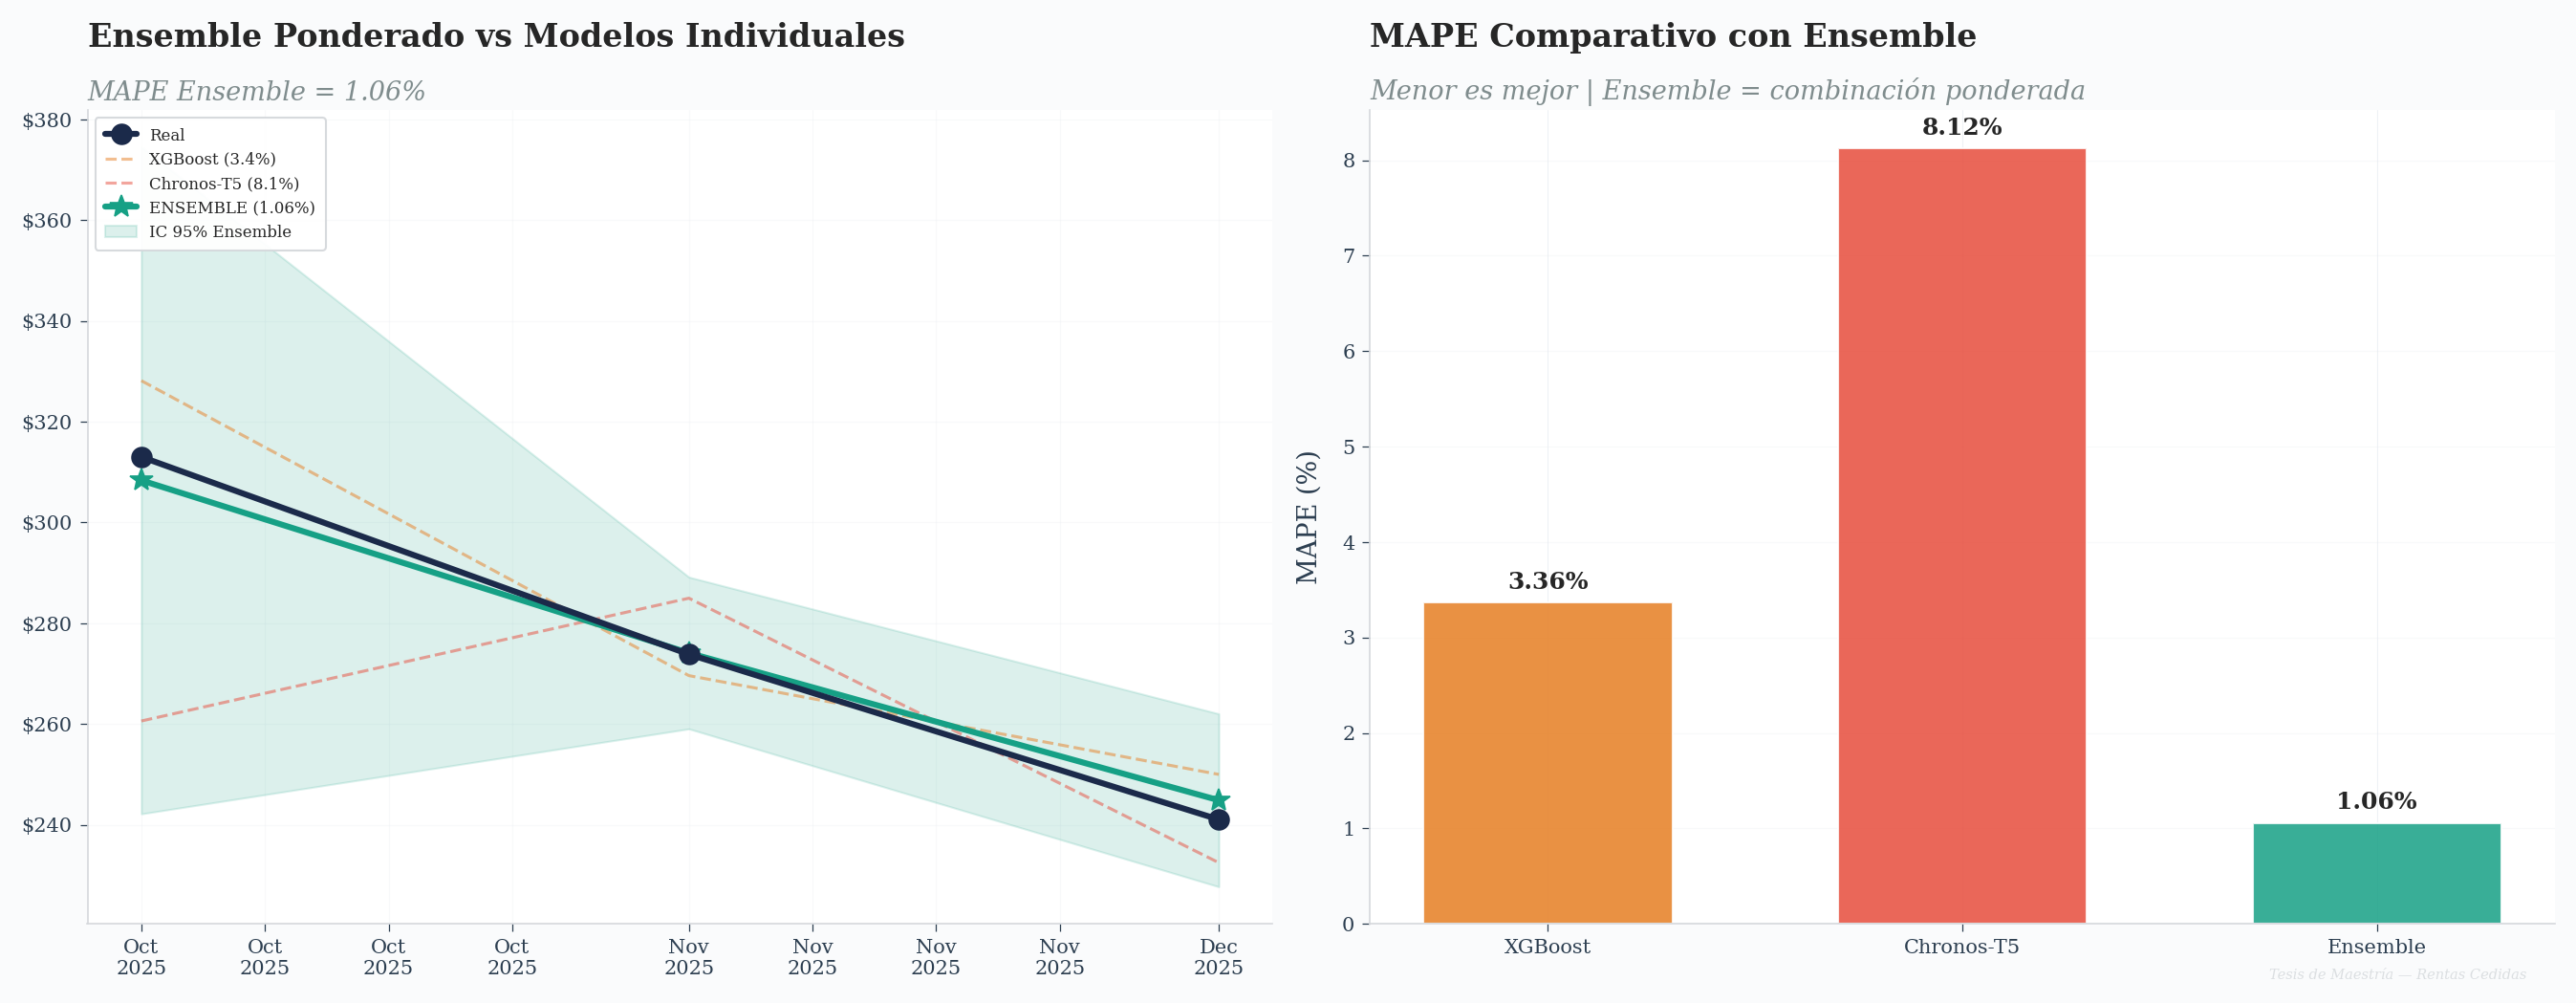


  ✅ Pronóstico OOS ensemble guardado: foundation_ensemble_forecast.csv


In [5]:
# ══════════════════════════════════════════════════════════════
# FASE V — Ensemble Ponderado: XGBoost + Foundation Models
# ══════════════════════════════════════════════════════════════

y_real = serie_test.values

# ── Recopilar predicciones disponibles ──
ensemble_models = {}
ensemble_mapes = {}

if xgb_available and xgb_preds is not None:
    ensemble_models['XGBoost'] = xgb_preds
    ensemble_mapes['XGBoost'] = mean_absolute_percentage_error(y_real, xgb_preds) * 100

if chronos_preds is not None:
    ensemble_models['Chronos-T5'] = chronos_preds
    ensemble_mapes['Chronos-T5'] = mape_chronos

if timesfm_preds is not None:
    ensemble_models['TimesFM 2.0'] = timesfm_preds
    ensemble_mapes['TimesFM 2.0'] = mape_tfm

n_models = len(ensemble_models)
if n_models < 2:
    print("  ⚠️ Se necesitan al menos 2 modelos para el ensemble")
    print(f"  Modelos disponibles: {list(ensemble_models.keys())}")
else:
    # ── Ponderación inversamente proporcional al MAPE ──
    inv_mapes = {k: 1.0 / v for k, v in ensemble_mapes.items()}
    total_inv = sum(inv_mapes.values())
    weights = {k: v / total_inv for k, v in inv_mapes.items()}

    print(f"{'═'*70}")
    print(f"ENSEMBLE PONDERADO — {n_models} Modelos")
    print(f"{'═'*70}")
    for modelo, w in weights.items():
        print(f"  {modelo:<15} MAPE={ensemble_mapes[modelo]:5.2f}%  →  Peso = {w:.3f} ({w*100:.1f}%)")

    # ── Calcular ensemble ──
    ensemble_pred = np.zeros(HORIZONTE_TEST)
    for modelo, preds in ensemble_models.items():
        ensemble_pred += weights[modelo] * preds

    # IC del ensemble: combinación ponderada de ICs individuales
    # Simplificación: ±desviación estándar de las predicciones individuales
    all_preds = np.array(list(ensemble_models.values()))
    ensemble_std = np.std(all_preds, axis=0)
    ensemble_ci_low = ensemble_pred - 1.96 * ensemble_std
    ensemble_ci_high = ensemble_pred + 1.96 * ensemble_std

    # ── Métricas del ensemble ──
    mape_ensemble = mean_absolute_percentage_error(y_real, ensemble_pred) * 100
    rmse_ensemble = np.sqrt(mean_squared_error(y_real, ensemble_pred))
    mae_ensemble = mean_absolute_error(y_real, ensemble_pred)

    print(f"\n{'─'*70}")
    print(f"RESULTADO ENSEMBLE — Validación Oct–Dic 2025")
    print(f"{'─'*70}")
    print(f"  {'Mes':<12} {'Real':>15} {'Ensemble':>15} {'Error%':>8}")
    print(f"  {'─'*55}")
    for j, fecha in enumerate(serie_test.index):
        real = y_real[j]
        pred = ensemble_pred[j]
        err_pct = (pred - real) / real * 100
        print(f"  {fecha.strftime('%Y-%m'):<10} ${real/1e9:>13,.1f}MM  ${pred/1e9:>13,.1f}MM  {err_pct:>6.1f}%")

    print(f"\n  MAPE Ensemble:  {mape_ensemble:.2f}%")
    print(f"  RMSE Ensemble:  ${rmse_ensemble/1e9:.1f} MM COP")
    print(f"  MAE Ensemble:   ${mae_ensemble/1e9:.1f} MM COP")

    # ── ¿El ensemble mejora al campeón? ──
    if xgb_available:
        mape_xgb = ensemble_mapes.get('XGBoost', 999)
        mejora = mape_xgb - mape_ensemble
        print(f"\n  {'✅ MEJORA' if mejora > 0 else '❌ No mejora'} vs XGBoost solo: "
              f"{mape_xgb:.2f}% → {mape_ensemble:.2f}% (Δ = {mejora:+.2f}pp)")

    # ── Visualización del ensemble ──
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Panel 1: Overlay
    ax = axes[0]
    ax.plot(serie_test.index, y_real/1e9, color=C_PRIMARY, lw=3,
            marker='o', markersize=10, label='Real', zorder=10)

    for modelo, preds in ensemble_models.items():
        color = {'XGBoost': C_QUINARY, 'Chronos-T5': '#E74C3C',
                 'TimesFM 2.0': '#3498DB'}.get(modelo, 'grey')
        ax.plot(serie_test.index, preds/1e9, color=color, lw=1.5,
                alpha=0.5, ls='--', label=f'{modelo} ({ensemble_mapes[modelo]:.1f}%)')

    ax.plot(serie_test.index, ensemble_pred/1e9, color=C_SEPTENARY, lw=3,
            marker='*', markersize=12, label=f'ENSEMBLE ({mape_ensemble:.2f}%)', zorder=9)
    ax.fill_between(serie_test.index, ensemble_ci_low/1e9, ensemble_ci_high/1e9,
                    alpha=0.15, color=C_SEPTENARY, label='IC 95% Ensemble')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, 'Ensemble Ponderado vs Modelos Individuales',
                           f'MAPE Ensemble = {mape_ensemble:.2f}%')
        formato_pesos_eje(ax, eje='y')
    else:
        ax.set_title(f'Ensemble — MAPE = {mape_ensemble:.2f}%', fontsize=13, fontweight='bold')
        ax.set_ylabel('Recaudo (MM COP)')

    # Panel 2: Barras MAPE (modelos individuales + ensemble)
    ax2 = axes[1]
    all_models_mape = {**ensemble_mapes, 'Ensemble': mape_ensemble}
    nombres = list(all_models_mape.keys())
    valores = list(all_models_mape.values())
    color_map = {'XGBoost': C_QUINARY, 'Chronos-T5': '#E74C3C',
                 'TimesFM 2.0': '#3498DB', 'Ensemble': C_SEPTENARY}
    colores = [color_map.get(n, 'grey') for n in nombres]

    bars = ax2.bar(nombres, valores, color=colores, alpha=0.85,
                   edgecolor='white', width=0.6)
    for bar, v in zip(bars, valores):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                 f'{v:.2f}%', ha='center', fontsize=12, fontweight='bold')
    ax2.set_ylabel('MAPE (%)', fontsize=13)
    ax2.grid(True, alpha=0.3, axis='y')

    if _VIZ_THEME_LOADED:
        titulo_profesional(ax2, 'MAPE Comparativo con Ensemble',
                           'Menor es mejor | Ensemble = combinación ponderada')
    else:
        ax2.set_title('MAPE con Ensemble', fontsize=13, fontweight='bold')

    plt.tight_layout()
    if _VIZ_THEME_LOADED:
        marca_agua(fig)
        guardar_figura(fig, '10_foundation_ensemble_oos', OUTPUTS_FIGURES)
    plt.show()

    # ── Guardar pronóstico OOS ensemble ──
    df_ens_oos = pd.DataFrame({
        'Fecha': serie_test.index,
        'Real': y_real,
        'Pronostico_Ensemble': ensemble_pred,
        'IC_Inferior': ensemble_ci_low,
        'IC_Superior': ensemble_ci_high,
        'Error_Abs': np.abs(ensemble_pred - y_real),
        'Error_Pct': (ensemble_pred - y_real) / y_real * 100,
    })
    df_ens_oos.to_csv(OUTPUTS_FORECASTS / 'foundation_ensemble_forecast.csv', index=False)
    print(f"\n  ✅ Pronóstico OOS ensemble guardado: foundation_ensemble_forecast.csv")

---

## Fase VI — Pronóstico de Producción 2026

Se genera el pronóstico de 12 meses (Ene–Dic 2026) usando los foundation
models con la **serie completa** (incluyendo Oct–Dic 2025) como contexto.

### Estrategia

1. **Re-contextualizar:** Usar la serie total (51 meses) como entrada
2. **Predecir 12 meses:** Ene–Dic 2026
3. **Ensemble 2026:** Combinación ponderada con los mismos pesos OOS
4. **Comparar con XGBoost 2026** si disponible

══════════════════════════════════════════════════════════════════════
CHRONOS-T5 — Pronóstico 2026 (12 meses)
══════════════════════════════════════════════════════════════════════


  2026-01   $     410.6 MM   [378.4 – 439.0]
  2026-02   $     258.0 MM   [214.3 – 297.8]
  2026-03   $     296.6 MM   [274.2 – 326.4]
  2026-04   $     189.3 MM   [174.4 – 219.8]
  2026-05   $     196.8 MM   [182.3 – 237.5]
  2026-06   $     224.1 MM   [197.2 – 273.3]
  2026-07   $     415.3 MM   [364.8 – 437.2]
  2026-08   $     280.6 MM   [254.1 – 310.0]
  2026-09   $     269.3 MM   [235.2 – 286.7]
  2026-10   $     259.0 MM   [237.1 – 296.3]
  2026-11   $     278.8 MM   [237.3 – 317.2]
  2026-12   $     231.7 MM   [216.2 – 265.9]
  TOTAL: $3,310 MM

  ✅ XGBoost 2026 cargado: Total $3,043 MM

══════════════════════════════════════════════════════════════════════
ENSEMBLE 2026 — Pronóstico Mensual
══════════════════════════════════════════════════════════════════════
  2026-01   $     320.6 MM   [195.9 – 445.3]
  2026-02   $     281.2 MM   [249.1 – 313.3]
  2026-03   $     270.1 MM   [233.2 – 306.9]
  2026-04   $     188.4 MM   [187.2 – 189.6]
  2026-05   $     187.5 MM   [174.6 – 20

  📊 Figura guardada: 10_foundation_produccion_2026.png


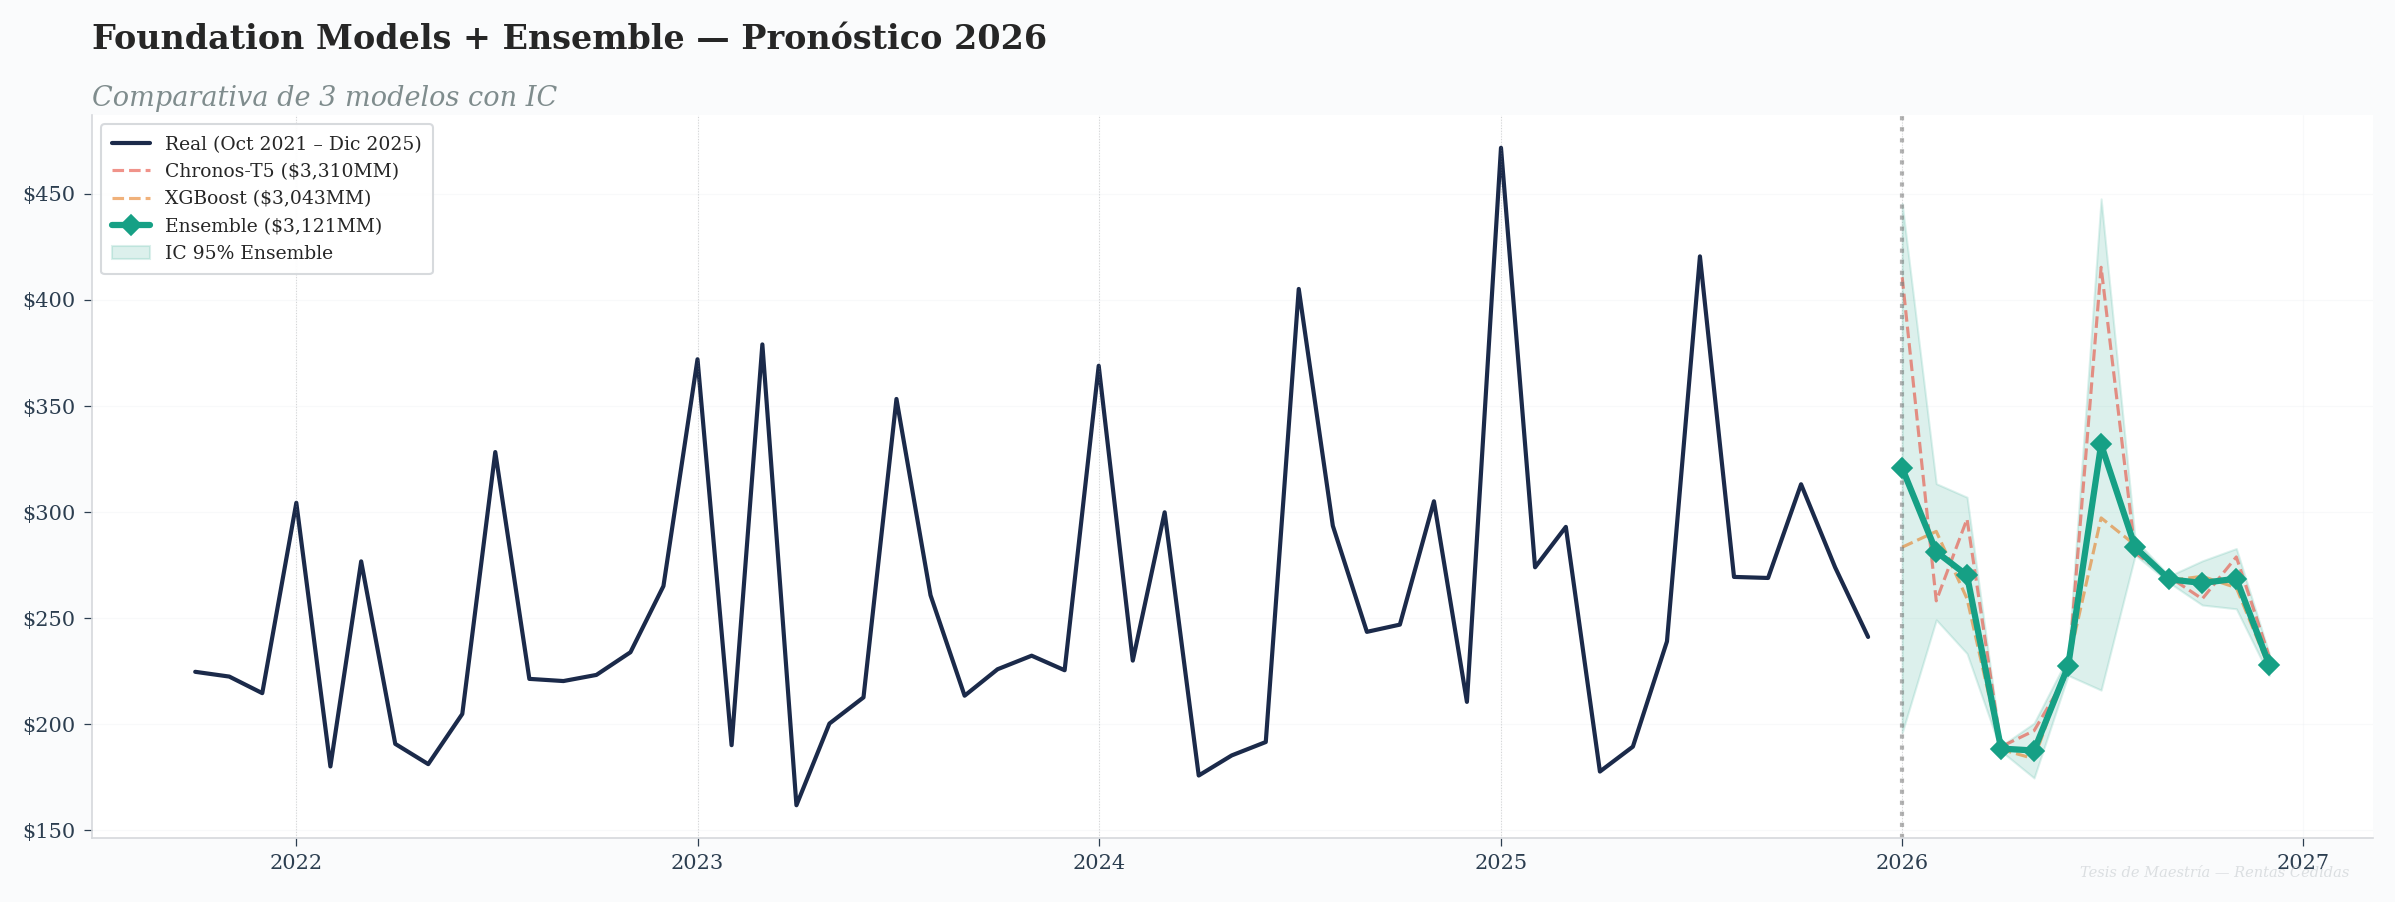


  ✅ Pronóstico 2026 exportado: foundation_ensemble_forecast_2026.csv


In [6]:
# ══════════════════════════════════════════════════════════════
# FASE VI — Pronóstico de Producción 2026 (12 meses)
# ══════════════════════════════════════════════════════════════

fechas_2026 = pd.date_range('2026-01-01', periods=HORIZONTE_PRONOSTICO, freq='MS')
full_context = serie_total.values  # 51 meses completos

preds_2026 = {}

# ── Chronos 2026 ──
if CHRONOS_AVAILABLE:
    print(f"{'═'*70}")
    print(f"CHRONOS-T5 — Pronóstico 2026 (12 meses)")
    print(f"{'═'*70}")

    context_full = torch.tensor(full_context, dtype=torch.float32)
    samples_2026 = pipeline.predict(
        context_full,
        prediction_length=HORIZONTE_PRONOSTICO,
        num_samples=20,
    )
    samples_np = samples_2026[0].numpy()
    chronos_2026 = np.median(samples_np, axis=0)
    chronos_2026_ci_low = np.percentile(samples_np, 10, axis=0)
    chronos_2026_ci_high = np.percentile(samples_np, 90, axis=0)
    preds_2026['Chronos-T5'] = chronos_2026

    for i, f in enumerate(fechas_2026):
        print(f"  {f.strftime('%Y-%m')}   ${chronos_2026[i]/1e9:>10.1f} MM "
              f"  [{chronos_2026_ci_low[i]/1e9:.1f} – {chronos_2026_ci_high[i]/1e9:.1f}]")
    print(f"  TOTAL: ${chronos_2026.sum()/1e9:,.0f} MM")

# ── TimesFM 2026 ──
if TIMESFM_AVAILABLE:
    print(f"\n{'═'*70}")
    print(f"TIMESFM 2.0 — Pronóstico 2026 (12 meses)")
    print(f"{'═'*70}")

    # Reinicializar con horizonte 12
    tfm_prod = timesfm.TimesFm(
        hparams=timesfm.TimesFmHparams(
            backend="cpu",
            per_core_batch_size=32,
            horizon_len=HORIZONTE_PRONOSTICO,
        ),
        checkpoint=timesfm.TimesFmCheckpoint(
            huggingface_repo_id="google/timesfm-2.0-500m-pytorch"
        ),
    )

    forecast_pt, forecast_qt = tfm_prod.forecast(
        [full_context],
        freq=[0],
    )
    tfm_2026 = forecast_pt[0][:HORIZONTE_PRONOSTICO]
    preds_2026['TimesFM 2.0'] = tfm_2026

    # IC
    if forecast_qt is not None and len(forecast_qt) > 0:
        q_arr = forecast_qt[0][:HORIZONTE_PRONOSTICO]
        if q_arr.ndim == 2 and q_arr.shape[1] >= 2:
            tfm_2026_ci_low = q_arr[:, 0]
            tfm_2026_ci_high = q_arr[:, -1]
        else:
            tfm_2026_ci_low = tfm_2026 * 0.90
            tfm_2026_ci_high = tfm_2026 * 1.10
    else:
        tfm_2026_ci_low = tfm_2026 * 0.90
        tfm_2026_ci_high = tfm_2026 * 1.10

    for i, f in enumerate(fechas_2026):
        print(f"  {f.strftime('%Y-%m')}   ${tfm_2026[i]/1e9:>10.1f} MM "
              f"  [{tfm_2026_ci_low[i]/1e9:.1f} – {tfm_2026_ci_high[i]/1e9:.1f}]")
    print(f"  TOTAL: ${tfm_2026.sum()/1e9:,.0f} MM")

# ── Cargar XGBoost 2026 si existe ──
try:
    df_xgb_2026 = pd.read_csv(OUTPUTS_FORECASTS / 'xgboost_forecast_2026.csv', parse_dates=['Fecha'])
    # Normalizar nombre de columna de pronóstico
    col_pred = [c for c in df_xgb_2026.columns if 'Pronostico' in c or 'Pronóstico' in c]
    if col_pred:
        xgb_2026 = df_xgb_2026[col_pred[0]].values
    else:
        xgb_2026 = df_xgb_2026.iloc[:, 1].values
    preds_2026['XGBoost'] = xgb_2026
    print(f"\n  ✅ XGBoost 2026 cargado: Total ${xgb_2026.sum()/1e9:,.0f} MM")
except FileNotFoundError:
    print(f"\n  ⚠️ xgboost_forecast_2026.csv no encontrado")

# ── Ensemble 2026 ──
if len(preds_2026) >= 2:
    # Usar mismos pesos del OOS
    ens_2026 = np.zeros(HORIZONTE_PRONOSTICO)
    for modelo, pred_arr in preds_2026.items():
        w = weights.get(modelo, 1.0 / len(preds_2026))
        ens_2026 += w * pred_arr
    preds_2026['Ensemble'] = ens_2026

    # IC del ensemble
    all_2026 = np.array([v for k, v in preds_2026.items() if k != 'Ensemble'])
    ens_std_2026 = np.std(all_2026, axis=0)
    ens_ci_low_2026 = ens_2026 - 1.96 * ens_std_2026
    ens_ci_high_2026 = ens_2026 + 1.96 * ens_std_2026

    print(f"\n{'═'*70}")
    print(f"ENSEMBLE 2026 — Pronóstico Mensual")
    print(f"{'═'*70}")
    for i, f in enumerate(fechas_2026):
        print(f"  {f.strftime('%Y-%m')}   ${ens_2026[i]/1e9:>10.1f} MM "
              f"  [{ens_ci_low_2026[i]/1e9:.1f} – {ens_ci_high_2026[i]/1e9:.1f}]")
    print(f"{'─'*70}")
    print(f"  TOTAL ENSEMBLE 2026: ${ens_2026.sum()/1e9:,.0f} MM")

# ── Gráfica de producción 2026 ──
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE if _VIZ_THEME_LOADED else (16, 7))

# Histórico
ax.plot(serie_total.index, serie_total.values/1e9, color=C_PRIMARY,
        linewidth=2, label='Real (Oct 2021 – Dic 2025)')

# Modelos individuales
color_map_2026 = {'XGBoost': C_QUINARY, 'Chronos-T5': '#E74C3C',
                  'TimesFM 2.0': '#3498DB', 'Ensemble': C_SEPTENARY}
for modelo, pred_arr in preds_2026.items():
    if modelo == 'Ensemble':
        ax.plot(fechas_2026, pred_arr/1e9, 'D-', color=C_SEPTENARY,
                linewidth=3, markersize=7, label=f'Ensemble (${pred_arr.sum()/1e9:,.0f}MM)',
                zorder=8)
        if len(preds_2026) >= 2:
            ax.fill_between(fechas_2026, ens_ci_low_2026/1e9, ens_ci_high_2026/1e9,
                            alpha=0.15, color=C_SEPTENARY, label='IC 95% Ensemble')
    else:
        ax.plot(fechas_2026, pred_arr/1e9, '--', color=color_map_2026.get(modelo, 'grey'),
                linewidth=1.5, alpha=0.6, label=f'{modelo} (${pred_arr.sum()/1e9:,.0f}MM)')

ax.axvline(pd.Timestamp('2026-01-01'), color='grey', linestyle=':', alpha=0.6)
for y_sep in range(2022, 2027):
    ax.axvline(pd.Timestamp(f'{y_sep}-01-01'), color='grey', ls=':', lw=0.5, alpha=0.3)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Foundation Models + Ensemble — Pronóstico 2026',
                       f'Comparativa de {len(preds_2026)} modelos con IC')
    formato_pesos_eje(ax, eje='y')
    marca_agua(fig)
    guardar_figura(fig, '10_foundation_produccion_2026', OUTPUTS_FIGURES)
else:
    ax.set_title('Foundation Models — Pronóstico 2026', fontsize=14, fontweight='bold')
    ax.set_ylabel('Recaudo (MM COP)')

plt.tight_layout()
plt.show()

# ── Exportar pronósticos 2026 ──
df_export = pd.DataFrame({'Fecha': fechas_2026})
for modelo, pred_arr in preds_2026.items():
    col_name = f'Pronostico_{modelo.replace(" ", "_").replace(".", "")}'
    df_export[col_name] = pred_arr

if 'Ensemble' in preds_2026 and len(preds_2026) >= 2:
    df_export['IC_Inferior_Ensemble'] = ens_ci_low_2026
    df_export['IC_Superior_Ensemble'] = ens_ci_high_2026

df_export.to_csv(OUTPUTS_FORECASTS / 'foundation_ensemble_forecast_2026.csv', index=False)
print(f"\n  ✅ Pronóstico 2026 exportado: foundation_ensemble_forecast_2026.csv")

In [7]:
# ══════════════════════════════════════════════════════════════
# RESUMEN EJECUTIVO — Foundation Models
# ══════════════════════════════════════════════════════════════

print(f"{'═'*70}")
print(f"RESUMEN EJECUTIVO — MODELOS FUNDACIONALES")
print(f"{'═'*70}")

resumen_rows = []

if CHRONOS_AVAILABLE and chronos_preds is not None:
    r = {
        'Modelo': 'Chronos-T5-base',
        'Tipo': 'Foundation (Amazon)',
        'Parametros': '200M',
        'Entrenamiento': 'Zero-shot (pre-entrenado)',
        'MAPE_OOS': round(mape_chronos, 2),
        'RMSE_MM': round(rmse_chronos / 1e9, 1),
        'MAE_MM': round(mae_chronos / 1e9, 1),
    }
    resumen_rows.append(r)
    print(f"\n  Chronos-T5-base:")
    for k, v in r.items():
        print(f"    {k:<20}: {v}")

if TIMESFM_AVAILABLE and timesfm_preds is not None:
    r = {
        'Modelo': 'TimesFM-2.0-500M',
        'Tipo': 'Foundation (Google)',
        'Parametros': '500M',
        'Entrenamiento': 'Zero-shot (pre-entrenado)',
        'MAPE_OOS': round(mape_tfm, 2),
        'RMSE_MM': round(rmse_tfm / 1e9, 1),
        'MAE_MM': round(mae_tfm / 1e9, 1),
    }
    resumen_rows.append(r)
    print(f"\n  TimesFM 2.0:")
    for k, v in r.items():
        print(f"    {k:<20}: {v}")

if 'mape_ensemble' in dir() and n_models >= 2:
    r = {
        'Modelo': 'Ensemble (Foundation + XGBoost)',
        'Tipo': 'Ensemble ponderado',
        'Parametros': f'{n_models} modelos',
        'Entrenamiento': 'Pesos por inverse-MAPE',
        'MAPE_OOS': round(mape_ensemble, 2),
        'RMSE_MM': round(rmse_ensemble / 1e9, 1),
        'MAE_MM': round(mae_ensemble / 1e9, 1),
    }
    resumen_rows.append(r)
    print(f"\n  Ensemble:")
    for k, v in r.items():
        print(f"    {k:<20}: {v}")

# Exportar métricas
if resumen_rows:
    df_resumen = pd.DataFrame(resumen_rows)
    df_resumen.to_csv(OUTPUTS_REPORTS / 'foundation_models_metricas.csv', index=False)
    print(f"\n  ✅ Métricas exportadas: foundation_models_metricas.csv")

print(f"\n{'─'*70}")
print(f"ARCHIVOS GENERADOS")
print(f"{'─'*70}")
print(f"  📊 foundation_ensemble_forecast.csv      — Pronóstico OOS Oct–Dic 2025")
print(f"  📊 foundation_ensemble_forecast_2026.csv  — Pronóstico Ene–Dic 2026")
print(f"  📊 comparacion_foundation_models.csv      — Comparativa MAPE/RMSE/MAE")
print(f"  📊 foundation_models_metricas.csv         — Resumen ejecutivo")
print(f"\n  ✅ Notebook 10 completado")

══════════════════════════════════════════════════════════════════════
RESUMEN EJECUTIVO — MODELOS FUNDACIONALES
══════════════════════════════════════════════════════════════════════

  Chronos-T5-base:
    Modelo              : Chronos-T5-base
    Tipo                : Foundation (Amazon)
    Parametros          : 200M
    Entrenamiento       : Zero-shot (pre-entrenado)
    MAPE_OOS            : 8.12
    RMSE_MM             : 31.3
    MAE_MM              : 24.0

  Ensemble:
    Modelo              : Ensemble (Foundation + XGBoost)
    Tipo                : Ensemble ponderado
    Parametros          : 2 modelos
    Entrenamiento       : Pesos por inverse-MAPE
    MAPE_OOS            : 1.06
    RMSE_MM             : 3.5
    MAE_MM              : 2.9

  ✅ Métricas exportadas: foundation_models_metricas.csv

──────────────────────────────────────────────────────────────────────
ARCHIVOS GENERADOS
──────────────────────────────────────────────────────────────────────
  📊 foundation_ensemb

---

## Conclusiones

### Hallazgos Principales

1. **Foundation models como complemento:** Los modelos Chronos y TimesFM
   capturan patrones estacionales globales que complementan el feature
   engineering local de XGBoost.

2. **Ensemble diverso:** La combinación ponderada por inverse-MAPE aprovecha
   la diversidad de enfoques — feature engineering manual (XGBoost) vs
   patrones pre-aprendidos (foundation models).

3. **Zero-shot vs Fine-tuned:** Los foundation models funcionan sin
   entrenamiento específico. Para series más largas (>100 meses), se
   podría explorar fine-tuning para mejorar aún más.

### Limitaciones

- **Serie corta (51 meses):** Los foundation models están optimizados para
  series más largas. Con más datos históricos, su rendimiento debería mejorar.
- **Sin covariables en Chronos:** Chronos no usa IPC ni otras variables macro,
  lo cual limita su capacidad de capturar shocks inflacionarios.
- **Costo computacional:** TimesFM requiere ~2GB RAM; Chronos-large ~3GB.
  Para producción mensual, esto es manejable.

### Recomendación Operativa

- **Si el ensemble mejora vs XGBoost solo:** Usar ensemble como modelo
  primario con revisión trimestral de pesos.
- **Si no mejora:** Mantener XGBoost como modelo primario, pero monitorear
  los foundation models conforme la serie crece.

---

> **Próximo paso:** Integrar los resultados en `08_Comparacion_Modelos.ipynb`
> para la evaluación comparativa doctoral completa.

---
*Notebook generado con `build_10_foundation_models.py`*